In [16]:
!pip install --upgrade xlrd

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 96 kB 5.1 MB/s 
  Attempting uninstall: xlrd
    Found existing installation: xlrd 1.1.0
    Uninstalling xlrd-1.1.0:
      Successfully uninstalled xlrd-1.1.0


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_excel("/content/measure.xls")
df.head()

,x1,x2,x3,x4,x5,x6,x7,y
0,94,80,70,77,99,85,79,83
1,91,82,76,91,79,96,93,87
2,86,82,72,92,99,78,92,86
3,88,79,77,75,80,78,82,80
4,93,82,77,75,79,76,89,82


In [2]:
print('데이터 세트의 Shape:', df.shape)
print('\n전체 feature 들의 type \n',df.dtypes.value_counts())
isnull_series = df.isnull().sum()
print('\nNull 컬럼과 그 건수:\n ', isnull_series[isnull_series > 0].sort_values(ascending=False))

데이터 세트의 Shape: (99, 8)

전체 feature 들의 type 
 int64    8
dtype: int64

Null 컬럼과 그 건수:
  Series([], dtype: int64)


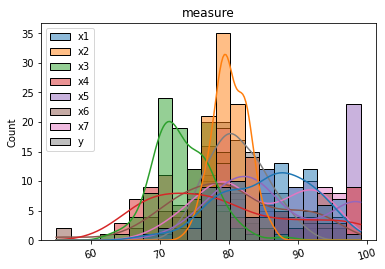

In [7]:
plt.title('measure')
plt.xticks(rotation=15)
sns.histplot(df, kde=True)
plt.show()

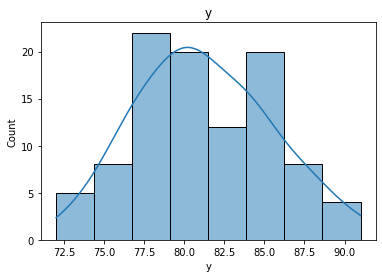

In [21]:
plt.title('y')

sns.histplot(df['y'], kde=True)
plt.show()

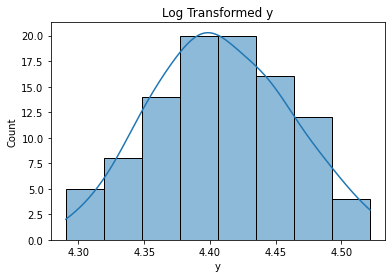

In [23]:
plt.title('Log Transformed y')

data = np.log1p(df['y'])
sns.histplot(data, kde=True)
plt.show()

In [24]:
# y 값 약간의 왜곡을 정규분포화 시킴(log이용)
original_y = df['y']
df['y'] = np.log1p(df['y'])

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# MAE, RMSE, RMSLE 반환
def evaluate_regr(y_test,pred):
    # MAE
    mae = mean_absolute_error(y_test,pred)
    
    # RMSLE
    log_y = np.log1p(y_test)
    log_pred = np.log1p(pred)
    msle = np.mean((log_y - log_pred) ** 2)
    rmsle = np.sqrt(msle)    
    
    print(f'MAE: {mae:.3f}, RMSLE: {rmsle:.3f}')

def get_rmse(model, X_test, y_test):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test , pred)
    rmse = np.sqrt(mse)
    evaluate_regr(y_test,pred)
    print('{0} 로그 변환된 RMSE: {1}'.format(model.__class__.__name__,np.round(rmse, 3)))
    print('')
    return rmse

def get_rmses(models, X_test, y_test):
    rmses = [ ]
    for model in models:
        rmse = get_rmse(model, X_test, y_test)
        rmses.append(rmse)
    return rmses

## 1~2, 회귀알고리즘 활용, 평가/비교 


In [46]:
# 회귀알고리즘을 2개 이상 활용
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

Y = df['y']
X = df.drop('y',axis=1, inplace=False)
     
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [47]:
# LinearRegression, Ridge, Lasso 학습, 예측, 평가
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)

ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)

lasso_reg = Lasso()
lasso_reg.fit(X_train, y_train)

models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models, X_test, y_test)

MAE: 0.004, RMSLE: 0.001
LinearRegression 로그 변환된 RMSE: 0.005

MAE: 0.004, RMSLE: 0.001
Ridge 로그 변환된 RMSE: 0.005

MAE: 0.044, RMSLE: 0.010
Lasso 로그 변환된 RMSE: 0.055



[0.004609564274198599, 0.004607768167484873, 0.055100377724729505]

**[ 2개 이상의 결과를 평가/비교 ]**
- Lasso 모델 보다 LinearRegression 모델이 더 평가척도가 좋다.


In [29]:
predictors = X_train.columns
predictors

Index(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7'], dtype='object')

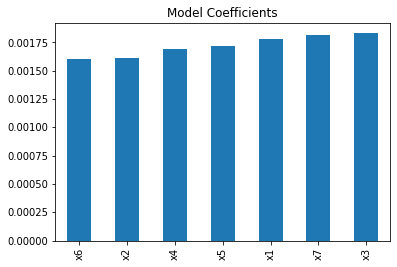

In [30]:
coef = pd.Series(lr_reg.coef_, predictors).sort_values()
coef.plot(kind='bar', title='Model Coefficients')

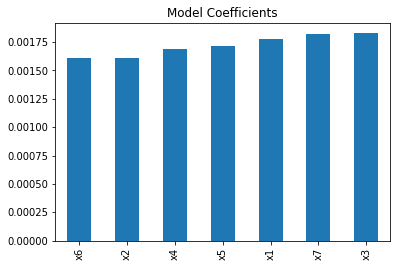

In [31]:
coef = pd.Series(ridge_reg.coef_, predictors).sort_values()
coef.plot(kind='bar', title='Model Coefficients')

In [48]:
# 하이퍼파리마터 튜닝

from sklearn.model_selection import GridSearchCV

Y = df['y']
X = df.drop('y',axis=1, inplace=False)
     
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

lr_reg = LinearRegression()
ridge_reg = Ridge()
lasso_reg = Lasso()

def print_best_params(model, params):
    grid_model = GridSearchCV(model, param_grid=params, 
                              scoring='neg_mean_squared_error', cv=5)
    grid_model.fit(X, Y)
    rmse = np.sqrt(-1* grid_model.best_score_)
    print('{0} 5 CV 시 최적 평균 RMSE 값: {1}, 최적 alpha:{2}'.format(model.__class__.__name__,
                                        np.round(rmse, 4), grid_model.best_params_))
    return grid_model.best_estimator_

ridge_params = { 'alpha':[0.05, 0.1, 1, 5, 8, 10, 12, 15, 20] }
lasso_params = { 'alpha':[0.001, 0.005, 0.008, 0.05, 0.03, 0.1, 0.5, 1,5, 10] }
best_rige = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

Ridge 5 CV 시 최적 평균 RMSE 값: 0.0043, 최적 alpha:{'alpha': 20}
Lasso 5 CV 시 최적 평균 RMSE 값: 0.0043, 최적 alpha:{'alpha': 0.001}


### Ridge - RMSE  0.004607  > 0.0045

In [62]:
# 회귀식 도출
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
ridge_reg = Ridge(alpha=20)
ridge_reg.fit(X_train, y_train)
lasso_reg = Lasso(alpha=0.001)
lasso_reg.fit(X_train, y_train)

# 모든 모델의 RMSE 출력
models = [lr_reg, ridge_reg, lasso_reg]
get_rmses(models, X_test, y_test)


MAE: 0.004, RMSLE: 0.001
LinearRegression 로그 변환된 RMSE: 0.005

MAE: 0.004, RMSLE: 0.001
Ridge 로그 변환된 RMSE: 0.005

MAE: 0.004, RMSLE: 0.001
Lasso 로그 변환된 RMSE: 0.005



[0.004609564274198599, 0.004584840315392188, 0.004602289563270835]

> Ridge 로그 변환된 0.00458  //  alpha 조금 조절하니, 0.004607 보다 성능이 조금 더 좋아졌다.


### XGBRegressor

In [51]:
from xgboost import XGBRegressor

xgb_params = {'n_estimators':[1000]}
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.05, 
                       colsample_bytree=0.5, subsample=0.8)
best_xgb = print_best_params(xgb_reg, xgb_params)

[12:49:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[12:49:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[12:49:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[12:49:53] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[12:49:54] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[12:49:54] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
XGBRegressor 5 CV 시 최적 평균 RMSE 값: 0.0135, 최적 alpha:{'n_estimators': 1000}


In [52]:
from lightgbm import LGBMRegressor

lgbm_params = {'n_estimators':[1000]}
lgbm_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=4, 
                         subsample=0.6, colsample_bytree=0.4, reg_lambda=10, n_jobs=-1)
best_lgbm = print_best_params(lgbm_reg, lgbm_params)

LGBMRegressor 5 CV 시 최적 평균 RMSE 값: 0.0146, 최적 alpha:{'n_estimators': 1000}


### 중요도 상위 5개의 피처

In [55]:
# 모델의 중요도 상위 5개의 피처명과 그때의 중요도값을 Series로 반환.
def get_top_features(model):
    ftr_importances_values = model.feature_importances_
    ftr_importances = pd.Series(ftr_importances_values, index=X.columns  )
    ftr_top5 = ftr_importances.sort_values(ascending=False)[:5]
    return ftr_top5

get_top_features(best_xgb)

x7    0.294725
x6    0.207961
x4    0.162483
x5    0.116466
x1    0.108856
dtype: float32

In [56]:
get_top_features(best_lgbm)

x1    491
x7    475
x4    452
x6    376
x5    333
dtype: int64

## 3. 회귀식 산출

In [66]:
# 회귀계수 출력
ridge_reg = Ridge(alpha=20)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)

ridge_reg.coef_

array([0.00177061, 0.00153442, 0.00176799, 0.00169434, 0.0017056 ,
       0.00161894, 0.00183014])

> 7개의 변수를 사용했기 때문에 회귀계수도 당연히 7개가 존재함.

In [67]:
# 절편
ridge_reg.intercept_  

3.4396950509845015

In [95]:
# 회귀식
a = ''
for i, c in enumerate(ridge_reg.coef_):
  # y = ax + b
  a += f'{str(round(np.exp(c),4))}x{i+1} + '

print('회귀식: y = ', a +  str(round(ridge_reg.intercept_,4)) )

회귀식: y =  1.0018x1 + 1.0015x2 + 1.0018x3 + 1.0017x4 + 1.0017x5 + 1.0016x6 + 1.0018x7 + 3.4397


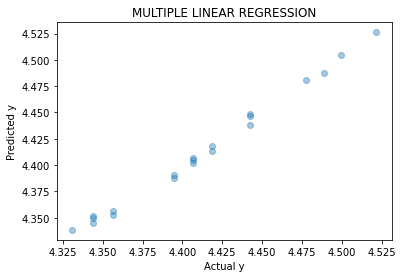

In [71]:
# 실제값과 예측값 비교
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("MULTIPLE LINEAR REGRESSION")
plt.show()


In [70]:
# 결정계수 확인
# 학습을 마친 모형에 test data 적용해서 결정계수 계산
print(ridge_reg.score(X_test, y_test))

0.993014928572405


In [79]:
# statsmodels 패키치 다중 선형 회귀
import statsmodels.formula.api as sm

result = sm.ols(formula = 'x1 ~ x2 + x7', data=df).fit()
print('절편과 기울기: ', result.params)
print()
print('유의확률: ', result.pvalues)
print()

print('결정계수: ', result.rsquared)

절편과 기울기:  Intercept    80.835690
x2           -0.222409
x7            0.268184
dtype: float64

유의확률:  Intercept    0.000194
x2           0.396295
x7           0.002312
dtype: float64

결정계수:  0.09329770438127816
